# NeuroDiffusion

EEG 시계열 데이터를 활용하여 Diffusion 기반 생성 모델을 학습하고, 희귀한 이상 뇌파(Harmful Brain Activity)를 증강하기 위한 프로젝트이다. 

먼저 데이터를 탐색하고, EEG를 Segment 단위로 변환한 뒤 Diffusion 모델 학습을 진행한다.

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("/Users/pitzsb1/Documents/HBAC/train.csv")

train.head()

# HMS 데이터에서 “어떤 이상 EEG가 얼마나 부족한지” 숫자로 확인

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


(106800, 15)
Index(['eeg_id', 'eeg_sub_id', 'eeg_label_offset_seconds', 'spectrogram_id',
       'spectrogram_sub_id', 'spectrogram_label_offset_seconds', 'label_id',
       'patient_id', 'expert_consensus', 'seizure_vote', 'lpd_vote',
       'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote'],
      dtype='str')
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64


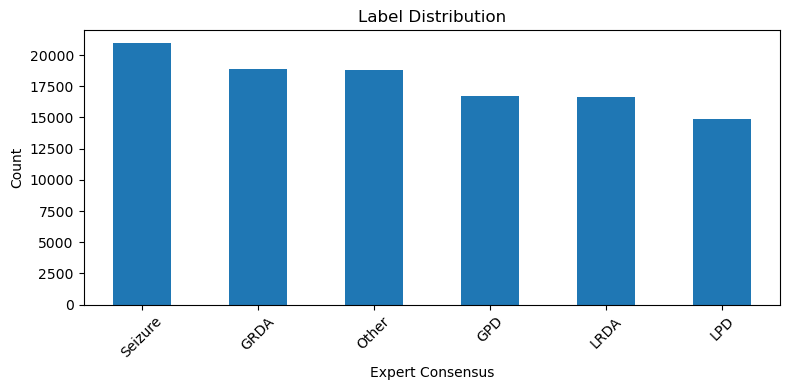

In [101]:
print(train.shape)
print(train.columns)
print(train["expert_consensus"].value_counts())

label_counts = train["expert_consensus"].value_counts()

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Expert Consensus")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

-> LPD (1st), LRDA/GPD

## 1. EEG 데이터 불러오기

HMS 데이터셋에서 EEG 파일을 직접 불러와 구조를 확인한다. EEG는 여러 채널(Fp1, F3, Cz 등)로 구성된 다변량 시계열 데이터이다.

In [102]:
import pandas as pd

# 예시 eeg_id 하나 뽑기
sample_id = train.iloc[0]["eeg_id"]

# parquet 불러오기
eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{sample_id}.parquet")

print(eeg.shape)
print(eeg.columns)
eeg.head()

(18000, 20)
Index(['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz',
       'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG'],
      dtype='str')


,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-80.519997,-70.540001,-80.110001,-108.750000,-120.330002,-88.620003,-101.750000,-104.489998,-99.129997,-90.389999,-97.040001,-77.989998,-88.830002,-112.120003,-108.110001,-95.949997,-98.360001,-121.730003,-106.449997,7.920000
1,-80.449997,-70.330002,-81.760002,-107.669998,-120.769997,-90.820000,-104.260002,-99.730003,-99.070000,-92.290001,-96.019997,-84.500000,-84.989998,-115.610001,-103.860001,-97.470001,-89.290001,-115.500000,-102.059998,29.219999
2,-80.209999,-75.870003,-82.050003,-106.010002,-117.500000,-87.489998,-99.589996,-96.820000,-119.680000,-99.360001,-91.110001,-99.440002,-104.589996,-127.529999,-113.349998,-95.870003,-96.019997,-123.879997,-105.790001,45.740002
3,-84.709999,-75.339996,-87.480003,-108.970001,-121.410004,-94.750000,-105.370003,-100.279999,-113.839996,-102.059998,-95.040001,-99.230003,-101.220001,-125.769997,-111.889999,-97.459999,-97.180000,-128.940002,-109.889999,83.870003
4,-90.570000,-80.790001,-93.000000,-113.870003,-129.960007,-102.860001,-118.599998,-101.099998,-107.660004,-102.339996,-98.510002,-95.300003,-88.930000,-115.639999,-99.800003,-97.500000,-88.730003,-114.849998,-100.250000,97.769997


### EEG 신호 시각화

특정 채널(Fp1)의 원시 파형을 확인하여 신호의 크기와 형태를 살펴본다.

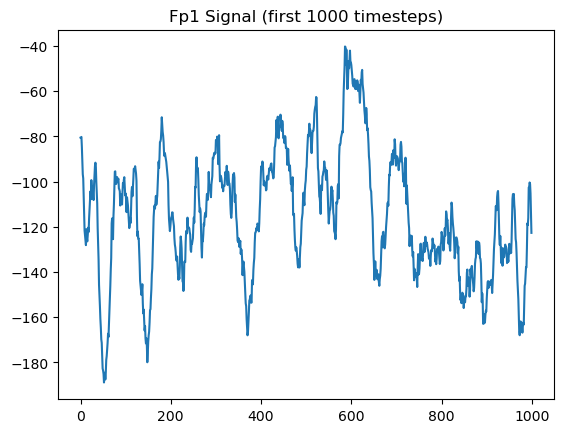

In [103]:
import matplotlib.pyplot as plt

# 한 채널만 보기 (예: Fp1)
plt.plot(eeg["Fp1"][:1000])
plt.title("Fp1 Signal (first 1000 timesteps)")
plt.show()

### EEG 분포 확인

각 채널의 값 분포를 확인하여 데이터가 생성 모델 학습에 적합한 형태인지 확인한다.

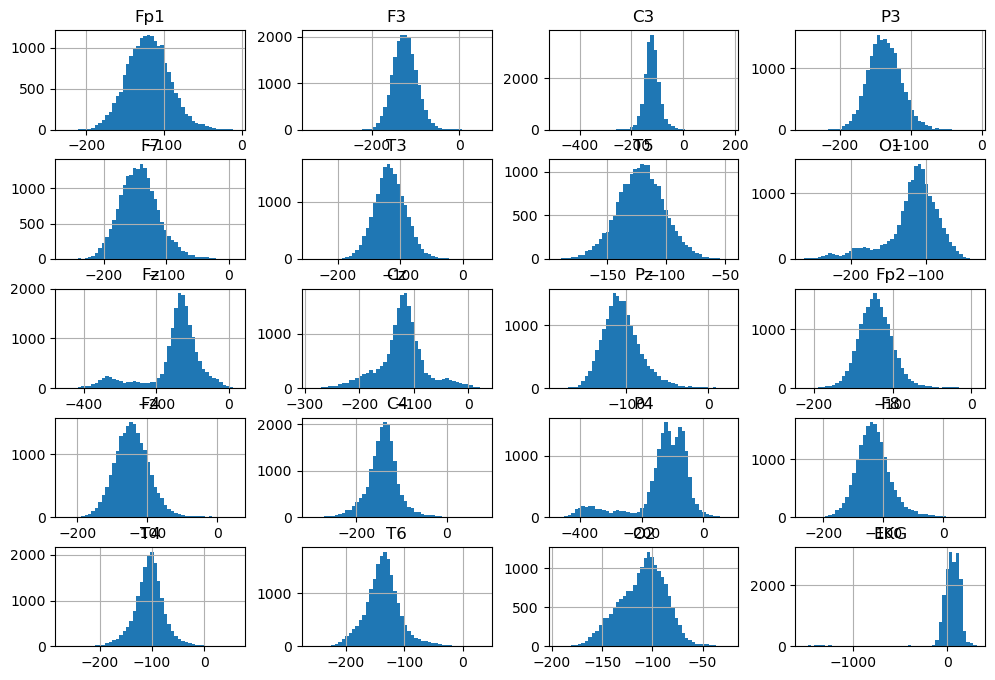

In [104]:
eeg.hist(figsize=(12,8), bins=50)
plt.show()

-> 대부분 종 모양(정규분포). Diffusion 데이터로 굿

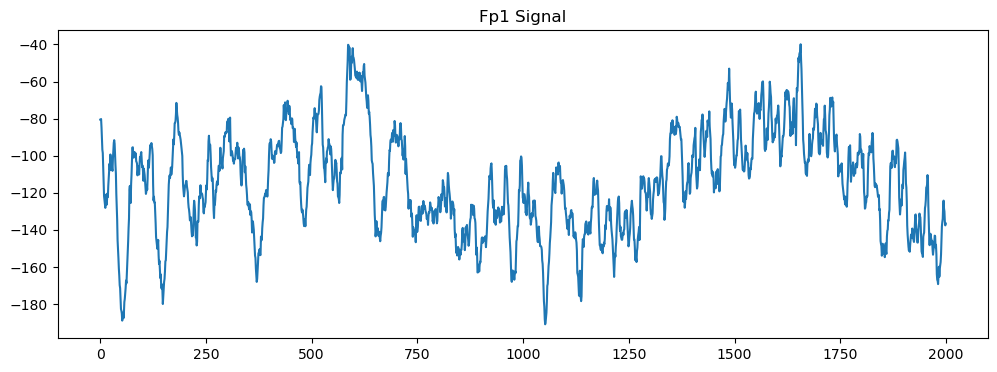

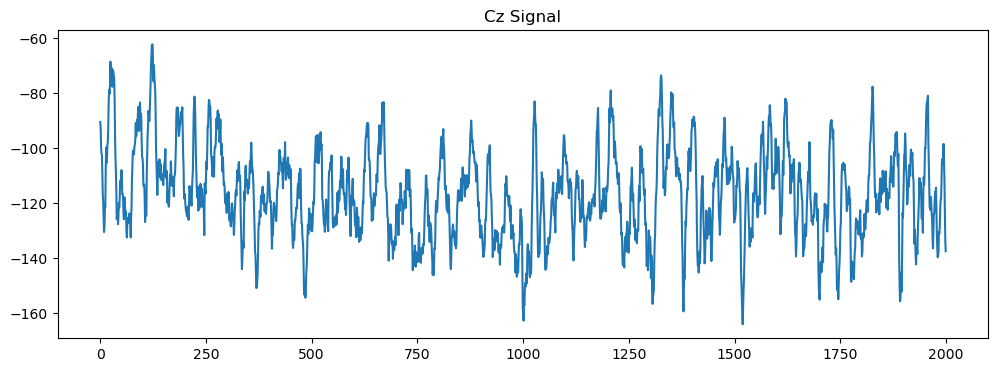

In [105]:
plt.figure(figsize=(12,4))
plt.plot(eeg["Fp1"][:2000])
plt.title("Fp1 Signal")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(eeg["Cz"][:2000])
plt.title("Cz Signal")
plt.show()

## 2. EEG 채널 정의

Diffusion 모델 입력으로 사용할 EEG 채널 목록을 정의한다. 일반적으로 EKG 채널은 제외하고 EEG 채널만 사용한다.

In [106]:
EEG_CHANNELS = [
    "Fp1", "F3", "C3", "P3", "F7", "T3", "T5", "O1",
    "Fz", "Cz", "Pz",
    "Fp2", "F4", "C4", "P4", "F8", "T4", "T6", "O2"
]

# 일단 EKG는 제외 

# NeuroStat 모델은 분석 모델이라 EKG 사용 가능, NeruoDiffusion 모델은 EEG 분포에 집중하는 생성 모델이기에 EKG는 제외하는 방향

## 3. EEG Segmentation

긴 EEG 신호를 일정 길이의 Segment로 분할한다. Diffusion 모델은 전체 EEG가 아닌 Segment 단위로 학습한다.

In [107]:
# EEG 하나를 Diffusion 입력용 segment로 자르기

import numpy as np

sampling_rate = 200
window_sec = 10
window_size = sampling_rate * window_sec  # 2000

segment = eeg[EEG_CHANNELS].iloc[:window_size].values
segment = segment.T

print(segment.shape)

(19, 2000)


### Segment 정규화

채널별 평균과 표준편차를 이용하여 정규화한다. 채널마다 스케일이 다르므로 안정적인 학습을 위해 필수적인 과정이다.

In [108]:
mean = segment.mean(axis=1, keepdims=True)
std = segment.std(axis=1, keepdims=True) + 1e-6

segment_norm = (segment - mean) / std

print(segment_norm.mean())
print(segment_norm.std())

-6.725914e-08
0.9999999


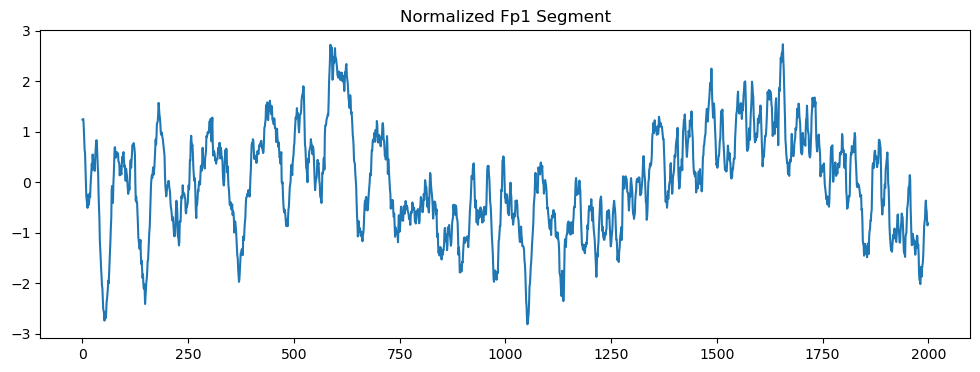

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(segment_norm[0])
plt.title("Normalized Fp1 Segment")
plt.show()

### Sliding Window 적용

하나의 EEG에서 여러 Segment를 생성하기 위해 Sliding Window 방식을 사용한다. 데이터 수를 증가시키고 다양한 패턴을 학습할 수 있다.

In [110]:
# 여러 segment 만들기 (sliding window)
# sliding window로 데이터 겹치게 자르기(같은 신호 여러 관점에서 확인)

def make_segments(eeg, window_size=2000, stride=1000):
    segments = []
    
    for start in range(0, len(eeg) - window_size, stride):
        seg = eeg.iloc[start:start+window_size][EEG_CHANNELS].values.T
        
        # normalization
        mean = seg.mean(axis=1, keepdims=True)
        std = seg.std(axis=1, keepdims=True) + 1e-6
        seg = (seg - mean) / std
        
        segments.append(seg)
    
    return segments

In [111]:
# EEG 하나에서 여러 segment 만들기

segments = make_segments(eeg)

print(len(segments))
print(segments[0].shape)

16
(19, 2000)


### 다수 EEG 처리

여러 EEG 파일에 대해 동일한 Segment 생성 과정을 반복하여 학습용 데이터를 구축한다.

In [112]:
# 여러 EEG에서 segment 만들기

all_segments = []

for i in range(100):  # 일단 100개만 테스트
    eeg_id = train.iloc[i]["eeg_id"]
    eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{eeg_id}.parquet")
    
    segs = make_segments(eeg)
    all_segments.extend(segs)

print(len(all_segments))

1304


In [113]:
# Pytorch는 리스트 못 읽기 때문에 numpy array로 바꿔주기

import numpy as np

X = np.array(all_segments)

print(X.shape)

(1304, 19, 2000)


### 레이블 연결

생성된 Segment에 원본 EEG의 expert_consensus 레이블을 부여한다.

In [114]:
# 각 segment에 레이블 붙이기

labels = []

for i in range(100):
    label = train.iloc[i]["expert_consensus"]
    
    eeg_id = train.iloc[i]["eeg_id"]
    eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{eeg_id}.parquet")
    
    segs = make_segments(eeg)
    
    labels.extend([label] * len(segs))

In [115]:
!pip install torch

## 4. PyTorch Dataset 구축

EEG Segment를 Dataset 형태로 변환하여 딥러닝 모델 학습에 사용할 수 있도록 준비한다.

In [116]:
import numpy as np

X = np.array(all_segments)

print(X.shape)

import torch
from torch.utils.data import Dataset

class EEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

dataset = EEGDataset(X)

(1304, 19, 2000)


### DataLoader 생성

배치 단위 학습을 위해 DataLoader를 구성한다.

In [117]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

batch = next(iter(dataloader))
print(batch.shape)

torch.Size([16, 19, 2000])


In [118]:
# torch dataset 만들기

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. list of segments -> numpy array
X = np.array(all_segments)

print("X shape:", X.shape)  # 예상: (1304, 19, 2000)

# 2. Torch Dataset
class EEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

# 3. dataset 객체 만들기
dataset = EEGDataset(X)

print("Dataset length:", len(dataset))
print("One sample shape:", dataset[0].shape)

# 4. DataLoader 만들기
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

# 5. batch 확인
batch = next(iter(dataloader))

print("Batch shape:", batch.shape)

X shape: (1304, 19, 2000)
Dataset length: 1304
One sample shape: torch.Size([19, 2000])
Batch shape: torch.Size([16, 19, 2000])


## 5. Diffusion 기본 개념

Diffusion 모델의 핵심 아이디어는 원본 데이터에 노이즈를 추가한 뒤, 모델이 해당 노이즈를 예측하고 제거하도록 학습하는 것이다.

In [119]:
# ★ Diffusion의 꽃... noise 추가하기
# eeg에 일부러 noise 섞기 -> 모델에게 noise 뭐였는지 맞히게 하기 -> 모델이 noise 제거하는 법 배우게 하기
# 나중에는 noise 섞인 eeg 줬을 때 원래 eeg 복원하는 모델로 발전시킬 수 있음
# Diffusion에 랜덤 노이즈를 넣어서, 새로운 eeg 신호를 생성 -> 데이터 증강!

import torch

def add_noise(x, noise_level=0.1):
    noise = torch.randn_like(x)
    x_noisy = x + noise_level * noise
    return x_noisy, noise

batch = next(iter(dataloader))

x_noisy, noise = add_noise(batch, noise_level=0.2)

print("Original:", batch.shape)
print("Noisy:", x_noisy.shape)
print("Noise:", noise.shape)

Original: torch.Size([16, 19, 2000])
Noisy: torch.Size([16, 19, 2000])
Noise: torch.Size([16, 19, 2000])


### Noise 추가 결과 시각화

원본 EEG와 노이즈가 추가된 EEG를 비교하여 Diffusion 학습 과정을 직관적으로 이해한다.

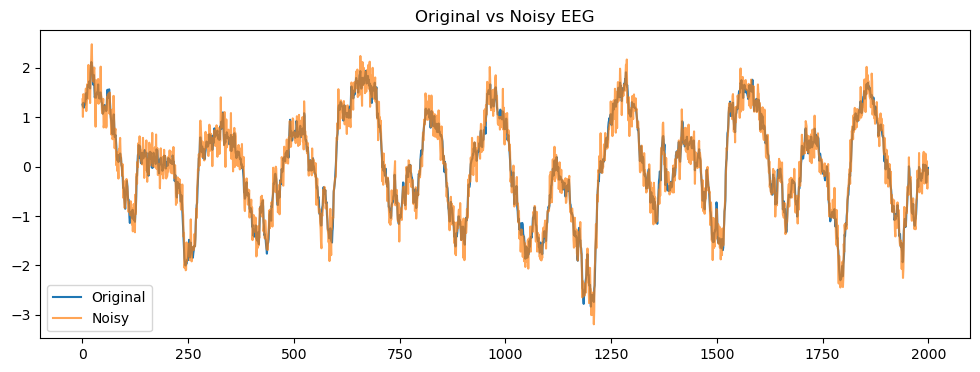

In [120]:
import matplotlib.pyplot as plt

sample_idx = 0
channel_idx = 0  # Fp1

plt.figure(figsize=(12,4))
plt.plot(batch[sample_idx, channel_idx].numpy(), label="Original")
plt.plot(x_noisy[sample_idx, channel_idx].numpy(), label="Noisy", alpha=0.7)
plt.legend()
plt.title("Original vs Noisy EEG")
plt.show()

## 6. Simple Denoiser 실험

Diffusion 전체 구조에 들어가기 전에 간단한 CNN 기반 Denoiser 모델로 노이즈 제거 개념을 실험한다.

In [121]:
# 간단한 모델 실험

import torch.nn as nn

class SimpleDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv1d(19, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Conv1d(64, 19, kernel_size=3, padding=1)
        )
    
    def forward(self, x):
        return self.net(x)

### Denoiser 학습

노이즈를 예측하도록 모델을 학습한다. 손실 함수는 MSE를 사용한다.

In [ ]:
model = SimpleDenoiser()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(3):
    for batch in dataloader:
        
        x = batch  # clean EEG
        noise = torch.randn_like(x) # random noise
        x_noisy = x + 0.2 * noise # noisy EEG
        
        pred_noise = model(x_noisy) # 모델이 noise 예측하게 하기
        
        loss = loss_fn(pred_noise, noise) # 모델이 예측한 noise와 실제 noise 비교
        
        optimizer.zero_grad() # gradient 초기화
        loss.backward() # backpropagation
        optimizer.step() # 모델 업데이트
    
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.9938
Epoch 1, Loss: 0.9636
Epoch 2, Loss: 0.9273


### Denoising 결과 확인

학습된 모델이 실제로 노이즈를 얼마나 제거하는지 시각적으로 확인한다.

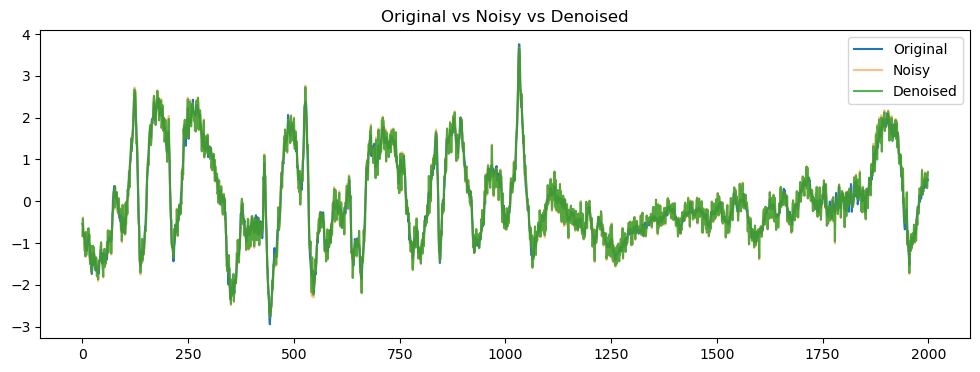

In [ ]:
# noise 제거 시각화

model.eval()

batch = next(iter(dataloader))
x = batch

noise = torch.randn_like(x)
x_noisy = x + 0.2 * noise

with torch.no_grad():
    pred_noise = model(x_noisy)
    x_denoised = x_noisy - 0.2 * pred_noise

import matplotlib.pyplot as plt

sample_idx = 0
channel_idx = 0

plt.figure(figsize=(12,4))
plt.plot(x[sample_idx, channel_idx].numpy(), label="Original")
plt.plot(x_noisy[sample_idx, channel_idx].numpy(), label="Noisy", alpha=0.5)
plt.plot(x_denoised[sample_idx, channel_idx].numpy(), label="Denoised", alpha=0.8)
plt.legend()
plt.title("Original vs Noisy vs Denoised")
plt.show()

In [ ]:
error_noisy = torch.abs(x_noisy - x)
error_denoised = torch.abs(x_denoised - x)

print("Noisy error:", error_noisy.mean().item())
print("Denoised error:", error_denoised.mean().item())

Noisy error: 0.1597994714975357
Denoised error: 0.15398764610290527


## 7. Diffusion Noise Schedule

Diffusion은 시간 단계(timestep)에 따라 노이즈 강도를 점진적으로 변화시킨다. 이를 위한 스케줄을 정의한다.

In [ ]:
# diffusion schedule (noise level 점점 줄이기)
# t = 0 -> 거의 깨끗, t = 50 -> 중간 정도, t = 99 -> 엄청 노이즈 많음

import torch

T = 100  # diffusion step 수

betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0) # 얼마나 원본이 남아있는지 보여주는 지표

print(alpha_bars.shape)

torch.Size([100])


### Forward Diffusion Process

원본 EEG에 timestep별 노이즈를 추가하는 q(x_t | x_0) 과정을 구현한다.

In [ ]:
# timestep에 따라 noise level 조절해서 EEG에 noise 추가 (실제로 이행)
# t 단계에 맞춰 노이즈 적절히 섞기

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    alpha_bar_t = alpha_bars[t].view(-1, 1, 1)

    x_noisy = torch.sqrt(alpha_bar_t) * x_start + torch.sqrt(1 - alpha_bar_t) * noise

    return x_noisy, noise

## 8. Time-aware Diffusion Model

Diffusion 모델은 현재 timestep 정보를 함께 입력받아 해당 단계의 노이즈를 예측해야 한다. 이를 위해 Time Embedding을 추가한다.

In [ ]:
# 모델이 timestep 정보도 같이 받도록 수정 (t에 따라 noise level 달라지니까)

import torch.nn as nn

class TimeEmbedding(nn.Module):
    def __init__(self, T, dim):
        super().__init__()
        self.embedding = nn.Embedding(T, dim)

    def forward(self, t):
        return self.embedding(t)


class DiffusionDenoiser(nn.Module):
    def __init__(self, T=100):
        super().__init__()

        self.time_embed = TimeEmbedding(T, 64)

        self.conv1 = nn.Conv1d(19, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(64, 19, kernel_size=3, padding=1)

        self.act = nn.ReLU()

    def forward(self, x, t):
        t_emb = self.time_embed(t)          # [B, 64]
        t_emb = t_emb.unsqueeze(-1)         # [B, 64, 1]

        h = self.conv1(x)                   # [B, 64, 2000]
        h = h + t_emb                       # timestep 정보 추가
        h = self.act(h)

        h = self.act(self.conv2(h))
        out = self.conv3(h)

        return out

### Diffusion 모델 학습

Time Embedding이 포함된 Diffusion Denoiser를 학습한다.

Device: mps
Epoch 1/50, Loss: 1.0067
Epoch 2/50, Loss: 0.9786
Epoch 3/50, Loss: 0.9356
Epoch 4/50, Loss: 0.8768
Epoch 5/50, Loss: 0.8185
Epoch 6/50, Loss: 0.7656
Epoch 7/50, Loss: 0.7102
Epoch 8/50, Loss: 0.6635
Epoch 9/50, Loss: 0.6346
Epoch 10/50, Loss: 0.6047
Epoch 11/50, Loss: 0.5951
Epoch 12/50, Loss: 0.5701
Epoch 13/50, Loss: 0.5501
Epoch 14/50, Loss: 0.5378
Epoch 15/50, Loss: 0.5287
Epoch 16/50, Loss: 0.5226
Epoch 17/50, Loss: 0.5257
Epoch 18/50, Loss: 0.5139
Epoch 19/50, Loss: 0.5089
Epoch 20/50, Loss: 0.5021
Epoch 21/50, Loss: 0.5002
Epoch 22/50, Loss: 0.4964
Epoch 23/50, Loss: 0.4947
Epoch 24/50, Loss: 0.4912
Epoch 25/50, Loss: 0.5014
Epoch 26/50, Loss: 0.4785
Epoch 27/50, Loss: 0.4884
Epoch 28/50, Loss: 0.4886
Epoch 29/50, Loss: 0.4812
Epoch 30/50, Loss: 0.4795
Epoch 31/50, Loss: 0.4807
Epoch 32/50, Loss: 0.4898
Epoch 33/50, Loss: 0.4764
Epoch 34/50, Loss: 0.4711
Epoch 35/50, Loss: 0.4747
Epoch 36/50, Loss: 0.4784
Epoch 37/50, Loss: 0.4720
Epoch 38/50, Loss: 0.4712
Epoch 39/

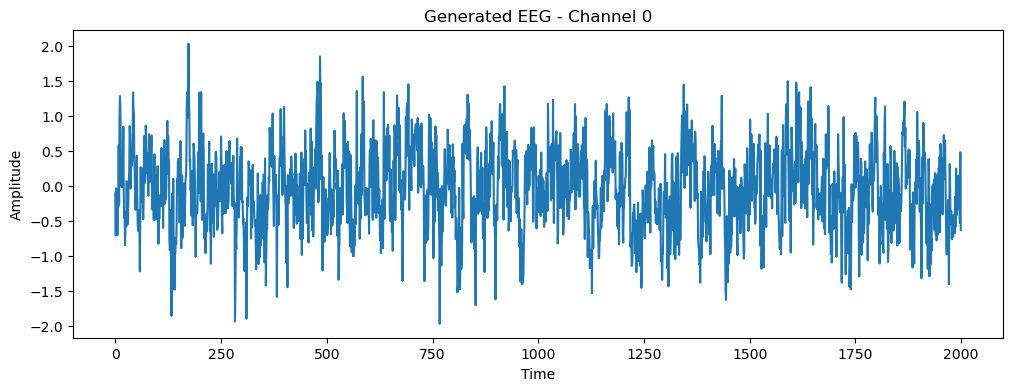

In [133]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================
# Step 1. Device 설정
# =========================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


# =========================
# Step 2. Diffusion 변수 재정의
# =========================

betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


# =========================
# Step 3. q_sample 함수 재정의
# =========================

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    alpha_bar_t = alpha_bars[t].view(-1, 1, 1)

    x_noisy = (
        torch.sqrt(alpha_bar_t) * x_start
        + torch.sqrt(1 - alpha_bar_t) * noise
    )

    return x_noisy, noise


# =========================
# Step 4. 모델 생성
# =========================

model = DiffusionDenoiser(T=T).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

num_epochs = 50


# =========================
# Step 5. 모델 학습
# =========================

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in dataloader:
        x = batch.to(device)

        batch_size = x.shape[0]

        t = torch.randint(
            0,
            T,
            (batch_size,),
            dtype=torch.long,
            device=device
        )

        x_noisy, noise = q_sample(x, t)

        pred_noise = model(x_noisy, t)

        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


# =========================
# Step 6. 샘플 생성 함수
# =========================

def sample(model, shape, T):
    model.eval()

    device = next(model.parameters()).device

    x = torch.randn(shape, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full(
            (shape[0],),
            t,
            dtype=torch.long,
            device=device
        )

        with torch.no_grad():
            pred_noise = model(x, t_batch)

        alpha = alphas[t]
        alpha_bar = alpha_bars[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
        ) + torch.sqrt(beta) * noise

    return x


# =========================
# Step 7. 생성 EEG 만들기
# =========================

generated = sample(model, shape=(1, 19, 2000), T=T)

print("Generated shape:", generated.shape)
print("Generated device:", generated.device)


# =========================
# Step 8. 생성 결과 시각화
# =========================

plt.figure(figsize=(12, 4))
plt.plot(generated[0, 0].detach().cpu().numpy())
plt.title("Generated EEG - Channel 0")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

-> 정규화된 EEG 느낌이긴 한데 주기성/패턴 없음

# 최종 통합 코드(EEG용 U-Net diffusion 코드)

지금 코드는 그대로 두고 모델 부분만 U-Net으로 갈아끼움

Device: mps
X shape: (6085, 19, 2000)
Batch shape: torch.Size([16, 19, 2000])
Model device: mps:0


/var/folders/47/s6m8yv7s6xb1fh8qf9m8m2h00000gn/T/ipykernel_15170/4111633926.py:237: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 19, 1001]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  real_fft = torch.abs(torch.fft.rfft(x, dim=-1))
/var/folders/47/s6m8yv7s6xb1fh8qf9m8m2h00000gn/T/ipykernel_15170/4111633926.py:238: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 19, 1001]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor 

Epoch 1/20 | Batch 0/381 | Total 1.0133 | Noise 1.0007 | FFT 0.2504
Epoch 1/20 | Batch 20/381 | Total 0.9984 | Noise 0.9898 | FFT 0.1716
Epoch 1/20 | Batch 40/381 | Total 0.9861 | Noise 0.9815 | FFT 0.0921
Epoch 1/20 | Batch 60/381 | Total 0.9696 | Noise 0.9633 | FFT 0.1259
Epoch 1/20 | Batch 80/381 | Total 0.9536 | Noise 0.9438 | FFT 0.1955
Epoch 1/20 | Batch 100/381 | Total 0.9065 | Noise 0.8986 | FFT 0.1592
Epoch 1/20 | Batch 120/381 | Total 0.8604 | Noise 0.8525 | FFT 0.1576
Epoch 1/20 | Batch 140/381 | Total 0.8185 | Noise 0.8119 | FFT 0.1327
Epoch 1/20 | Batch 160/381 | Total 0.8438 | Noise 0.8376 | FFT 0.1248
Epoch 1/20 | Batch 180/381 | Total 0.8112 | Noise 0.8070 | FFT 0.0829
Epoch 1/20 | Batch 200/381 | Total 0.7014 | Noise 0.6966 | FFT 0.0957
Epoch 1/20 | Batch 220/381 | Total 0.7465 | Noise 0.7385 | FFT 0.1598
Epoch 1/20 | Batch 240/381 | Total 0.7298 | Noise 0.7249 | FFT 0.0970
Epoch 1/20 | Batch 260/381 | Total 0.6108 | Noise 0.5998 | FFT 0.2203
Epoch 1/20 | Batch 280/381

/var/folders/47/s6m8yv7s6xb1fh8qf9m8m2h00000gn/T/ipykernel_15170/4111633926.py:237: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [5, 19, 1001]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  real_fft = torch.abs(torch.fft.rfft(x, dim=-1))
/var/folders/47/s6m8yv7s6xb1fh8qf9m8m2h00000gn/T/ipykernel_15170/4111633926.py:238: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [5, 19, 1001]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t 

Epoch 1/20 | Batch 380/381 | Total 0.6491 | Noise 0.6441 | FFT 0.1004
Epoch 1/20, Avg Loss: 0.7766 ✅ saved
Epoch 2/20 | Batch 0/381 | Total 0.5679 | Noise 0.5609 | FFT 0.1407
Epoch 2/20 | Batch 20/381 | Total 0.5658 | Noise 0.5600 | FFT 0.1164
Epoch 2/20 | Batch 40/381 | Total 0.4966 | Noise 0.4914 | FFT 0.1024
Epoch 2/20 | Batch 60/381 | Total 0.5755 | Noise 0.5673 | FFT 0.1641
Epoch 2/20 | Batch 80/381 | Total 0.4742 | Noise 0.4683 | FFT 0.1193
Epoch 2/20 | Batch 100/381 | Total 0.4832 | Noise 0.4787 | FFT 0.0890
Epoch 2/20 | Batch 120/381 | Total 0.5043 | Noise 0.4986 | FFT 0.1148
Epoch 2/20 | Batch 140/381 | Total 0.5116 | Noise 0.5011 | FFT 0.2105
Epoch 2/20 | Batch 160/381 | Total 0.5124 | Noise 0.5080 | FFT 0.0873
Epoch 2/20 | Batch 180/381 | Total 0.4840 | Noise 0.4794 | FFT 0.0920
Epoch 2/20 | Batch 200/381 | Total 0.4813 | Noise 0.4770 | FFT 0.0857
Epoch 2/20 | Batch 220/381 | Total 0.4413 | Noise 0.4331 | FFT 0.1631
Epoch 2/20 | Batch 240/381 | Total 0.4023 | Noise 0.3956 | 

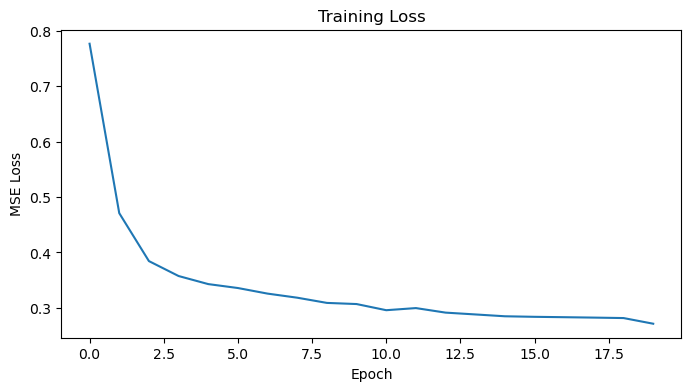

Generated shape: torch.Size([1, 19, 2000])


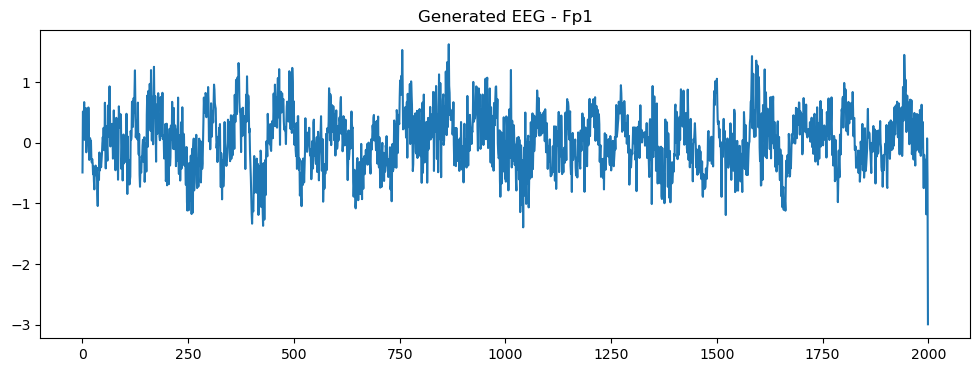

In [138]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# =========================
# 1. 설정
# =========================

EEG_CHANNELS = [
    "Fp1", "F3", "C3", "P3", "F7", "T3", "T5", "O1",
    "Fz", "Cz", "Pz",
    "Fp2", "F4", "C4", "P4", "F8", "T4", "T6", "O2"
]

sampling_rate = 200
window_sec = 10
window_size = sampling_rate * window_sec

stride = 500
T = 100
num_epochs = 20
batch_size = 16

train_csv_path = "/Users/pitzsb1/Documents/HBAC/train.csv"
eeg_dir = "/Users/pitzsb1/Documents/train_eegs"
save_path = "/Users/pitzsb1/Desktop/NeuroDiffusion/best_unet_diffusion_model.pth"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

# =========================
# 2. Segment 생성
# =========================

def make_segments(eeg, window_size=2000, stride=500):
    segments = []

    for start in range(0, len(eeg) - window_size, stride):
        seg = eeg.iloc[start:start+window_size][EEG_CHANNELS].values.T

        mean = seg.mean(axis=1, keepdims=True)
        std = seg.std(axis=1, keepdims=True) + 1e-6
        seg = (seg - mean) / std

        segments.append(seg)

    return segments

train = pd.read_csv(train_csv_path)

all_segments = []
num_files = 200

for i in range(num_files):
    eeg_id = train.iloc[i]["eeg_id"]
    path = f"{eeg_dir}/{eeg_id}.parquet"

    eeg = pd.read_parquet(path)
    segs = make_segments(eeg, window_size=window_size, stride=stride)
    all_segments.extend(segs)

X = np.array(all_segments, dtype=np.float32)

print("X shape:", X.shape)

# =========================
# 3. Dataset / DataLoader
# =========================

class EEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

dataset = EEGDataset(X)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

batch = next(iter(dataloader))
print("Batch shape:", batch.shape)

# =========================
# 4. Diffusion Schedule
# =========================

betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    alpha_bar_t = alpha_bars[t].view(-1, 1, 1)
    x_noisy = torch.sqrt(alpha_bar_t) * x_start + torch.sqrt(1 - alpha_bar_t) * noise

    return x_noisy, noise

# =========================
# 5. EEG용 1D U-Net Model
# =========================

class UNet1DDenoiser(nn.Module):
    def __init__(self, T=100, base_ch=64):
        super().__init__()

        self.time_embed = nn.Embedding(T, base_ch * 4)

        self.enc1 = nn.Sequential(
            nn.Conv1d(19, base_ch, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(base_ch, base_ch, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.down1 = nn.Conv1d(base_ch, base_ch * 2, kernel_size=4, stride=2, padding=1)

        self.enc2 = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 2, base_ch * 2, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.down2 = nn.Conv1d(base_ch * 2, base_ch * 4, kernel_size=4, stride=2, padding=1)

        self.mid = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 4, base_ch * 4, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(base_ch * 4, base_ch * 4, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose1d(base_ch * 4, base_ch * 2, kernel_size=4, stride=2, padding=1)

        self.dec1 = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 4, base_ch * 2, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.up2 = nn.ConvTranspose1d(base_ch * 2, base_ch, kernel_size=4, stride=2, padding=1)

        self.dec2 = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(base_ch * 2, base_ch, kernel_size=7, padding=3),
            nn.ReLU()
        )

        self.out = nn.Conv1d(base_ch, 19, kernel_size=7, padding=3)

    def forward(self, x, t):
        t_emb = self.time_embed(t).unsqueeze(-1)

        e1 = self.enc1(x)
        d1 = self.down1(e1)

        e2 = self.enc2(d1)
        d2 = self.down2(e2)

        mid = d2 + t_emb
        mid = self.mid(mid)

        u1 = self.up1(mid)
        u1 = torch.cat([u1, e2], dim=1)
        u1 = self.dec1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, e1], dim=1)
        u2 = self.dec2(u2)

        return self.out(u2)

model = UNet1DDenoiser(T=T, base_ch=64).to(device)

print("Model device:", next(model.parameters()).device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# =========================
# 6. Training Loop
# =========================

loss_history = []
best_loss = float("inf")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(dataloader):
        x = batch.to(device)

        batch_size_now = x.shape[0]
        t = torch.randint(0, T, (batch_size_now,), device=device)

        x_noisy, noise = q_sample(x, t)
        pred_noise = model(x_noisy, t)

        # =========================
        # Frequency-aware Loss
        # =========================

        # 1. 기본 diffusion noise prediction loss
        noise_loss = loss_fn(pred_noise, noise)

        # 2. 예측 noise를 제거해서 x0 복원 추정
        alpha_bar_t = alpha_bars[t].view(-1, 1, 1)

        x_recon = (
            x_noisy - torch.sqrt(1 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        # 3. FFT 계산
        real_fft = torch.abs(torch.fft.rfft(x, dim=-1))
        recon_fft = torch.abs(torch.fft.rfft(x_recon, dim=-1))

        # 4. 주파수 축 생성
        freqs = torch.fft.rfftfreq(
            x.shape[-1],
            d=1 / sampling_rate
        ).to(device)

        # 5. EEG 주요 대역만 사용: 0.5~40Hz
        freq_mask = (freqs >= 0.5) & (freqs <= 40)

        real_fft = real_fft[:, :, freq_mask]
        recon_fft = recon_fft[:, :, freq_mask]

        # 6. log 변환으로 큰 peak가 loss를 지배하지 않게 함
        real_fft = torch.log1p(real_fft)
        recon_fft = torch.log1p(recon_fft)

        # 7. 각 샘플/채널별 정규화
        real_fft = real_fft / (real_fft.mean(dim=-1, keepdim=True) + 1e-6)
        recon_fft = recon_fft / (recon_fft.mean(dim=-1, keepdim=True) + 1e-6)

        # 8. FFT loss
        fft_loss = loss_fn(recon_fft, real_fft)

        # 9. 최종 loss
        fft_weight = 0.05
        loss = noise_loss + fft_weight * fft_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Batch {batch_idx}/{len(dataloader)} | "
                f"Total {loss.item():.4f} | "
                f"Noise {noise_loss.item():.4f} | "
                f"FFT {fft_loss.item():.4f}"
    )

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), save_path)
        print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f} ✅ saved")
    else:
        print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f}")

# =========================
# 7. Loss Plot
# =========================

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# =========================
# 8. Best Model Load
# =========================

model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

# =========================
# 9. Reverse Sampling
# =========================

def sample(model, shape, T):
    model.eval()
    x = torch.randn(shape, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((shape[0],), t, dtype=torch.long, device=device)

        with torch.no_grad():
            pred_noise = model(x, t_batch)

        alpha = alphas[t]
        alpha_bar = alpha_bars[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
        ) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise
        ) + torch.sqrt(beta) * noise

    return x

generated = sample(model, shape=(1, 19, 2000), T=T)

print("Generated shape:", generated.shape)

# =========================
# 10. Plot Generated EEG
# =========================

generated_cpu = generated.detach().cpu()

plt.figure(figsize=(12, 4))
plt.plot(generated_cpu[0, 0].numpy())
plt.title("Generated EEG - Fp1")
plt.show()

# FFT(Fast Fourier Transform)

시간 그래프 → 주파수 그래프로 변환

예를 들어

원래:

"~~~~~~~" 이렇게 보이던 신호를

FFT하면: 0Hz 성분 강함, 20Hz 성분 약함

이제 Real EEG, Generated EEG의 FFT를 비교해서 생성 데이터가 진짜 EEG의 주파수 구조를 학습했는가? 확인

## Step 1. Real EEG와 Generated EEG 추출

FFT 비교를 위해 실제 EEG와 생성 EEG를 준비한다.

첫 번째 segment의 Fp1 채널을 사용한다.

In [139]:
# Real EEG (Fp1)

real = X[0, 0]

# Generated EEG (Fp1)

gen = generated[0, 0].detach().cpu().numpy()

print(real.shape)
print(gen.shape)

(2000,)
(2000,)


## Step 2. FFT 계산

FFT(Fast Fourier Transform)를 이용하여
시간 영역(Time Domain)의 EEG 신호를
주파수 영역(Frequency Domain)으로 변환한다.

이를 통해 EEG 내부의 주파수 성분을 확인할 수 있다.

In [140]:
import numpy as np

# FFT 계산

real_fft = np.abs(np.fft.rfft(real))
gen_fft = np.abs(np.fft.rfft(gen))

# 주파수 축 생성

freqs = np.fft.rfftfreq(
    len(real),
    d=1/200
)

print(real_fft.shape)
print(gen_fft.shape)

(1001,)
(1001,)


## Step 3. FFT 비교 시각화

실제 EEG와 생성 EEG의 주파수 스펙트럼을 비교한다.

만약 생성 EEG가 실제 EEG의 주요 주파수 성분을 재현한다면,
두 그래프의 peak 위치가 유사하게 나타난다.

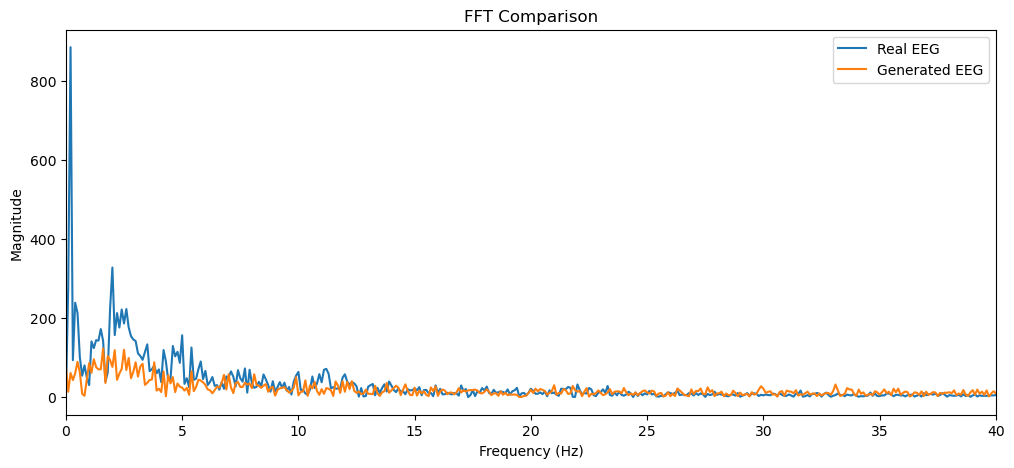

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    freqs,
    real_fft,
    label="Real EEG"
)

plt.plot(
    freqs,
    gen_fft,
    label="Generated EEG"
)

plt.xlim(0,40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.title("FFT Comparison")

plt.legend()

plt.show()

생성 데이터는 실제 EEG와 유사한 amplitude 분포를 보였으나, FFT 분석 결과 특정 저주파 peak를 충분히 재현하지 못 함

이는 통계적 특성은 학습했으나 EEG 고유의 리듬 구조 학습은 부족함을 의미

1. Diffusion 구축

2. 생성 성공

3. FFT 평가

4. 저주파 리듬 부족 발견

5. 원인 분석

→ 현재 U-Net은 frequency-aware 구조가 아님

Limitations

현재 모델은 시간 영역 기반 U-Net 구조를 사용하므로
EEG의 주파수 구조를 충분히 반영하지 못하였다.

# 1. Real vs Generated 통계 비교

## Step 1. Real EEG와 Generated EEG 준비

생성 데이터 평가를 위해 실제 EEG segment와 생성 EEG segment를 준비

- Real EEG: 학습 데이터에서 가져온 실제 segment
- Generated EEG: diffusion 모델이 생성한 segment

두 데이터 모두 shape이 `(19, 2000)`인지 확인

In [143]:
# 실제 EEG 하나 선택
real_sample = X[0]  # shape: (19, 2000)

# 생성 EEG 하나 선택
gen_sample = generated[0].detach().cpu().numpy()  # shape: (19, 2000)

print("Real shape:", real_sample.shape)
print("Generated shape:", gen_sample.shape)

Real shape: (19, 2000)
Generated shape: (19, 2000)


## Step 2. Statistical Feature Comparison

생성 EEG가 실제 EEG와 유사한 통계적 특성을 가지는지 확인

비교 항목:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Range

만약 생성 EEG가 실제 EEG와 유사한 통계량을 가진다면,
신호의 amplitude 분포를 어느 정도 학습했다고 해석할 수 있음

In [144]:
import pandas as pd
import numpy as np

def get_stats(signal):

    return {
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Min": np.min(signal),
        "Max": np.max(signal),
        "Range": np.max(signal) - np.min(signal)
    }

real_stats = get_stats(real_sample)
gen_stats = get_stats(gen_sample)

stats_df = pd.DataFrame({
    "Real EEG": real_stats,
    "Generated EEG": gen_stats
})

stats_df

,Real EEG,Generated EEG
Mean,-6.725914e-08,-0.002637
Std,9.999999e-01,0.475501
Min,-4.979223e+00,-3.680194
Max,4.146091e+00,3.123215
Range,9.125314e+00,6.803410


실제 EEG와 생성 EEG의 통계량을 비교한 결과,
Mean은 유사하게 유지되었으나
Standard Deviation과 Range는 감소

이는 모델이 EEG 신호의 중심 분포는 학습하였으나,
실제 EEG에서 나타나는 진폭 변동성을 충분히 재현하지 못했음을 의미

## Step 3. EEG Band Power Comparison

EEG는 시간 파형뿐 아니라
주파수 구조가 매우 중요

따라서 FFT를 이용하여
각 EEG 주파수 대역의 에너지를 계산한

비교 대역:

- Delta (0.5–4 Hz)
- Theta (4–8 Hz)
- Alpha (8–13 Hz)
- Beta (13–30 Hz)
- Gamma (30–40 Hz)

이를 통해 생성 EEG가 실제 EEG의
주파수 구조를 얼마나 재현하는지 평가

In [145]:
def compute_band_power(signal, sampling_rate=200):

    freqs = np.fft.rfftfreq(
        signal.shape[-1],
        d=1/sampling_rate
    )

    fft_power = np.abs(
        np.fft.rfft(signal, axis=-1)
    ) ** 2

    bands = {
        "Delta": (0.5, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta": (13, 30),
        "Gamma": (30, 40)
    }

    result = {}

    for band, (low, high) in bands.items():

        mask = (freqs >= low) & (freqs < high)

        result[band] = fft_power[:, mask].mean()

    return result


real_band = compute_band_power(real_sample)
gen_band = compute_band_power(gen_sample)

band_df = pd.DataFrame({
    "Real EEG": real_band,
    "Generated EEG": gen_band
})

band_df

,Real EEG,Generated EEG
Delta,21815.199751,4335.030729
Theta,10530.423966,1479.421153
Alpha,3877.992256,753.007036
Beta,462.195954,248.245660
Gamma,137.026502,169.783791


Band Power 분석 결과,
생성 EEG는 실제 EEG 대비 Delta 및 Theta 대역의 에너지가 크게 감소

반면 Beta 및 Gamma 대역은 상대적으로 유사한 수준을 유지 ✓

이는 현재 Diffusion 모델이 단기적인 신호 구조는 일부 학습하였으나,
EEG의 핵심적인 저주파 리듬(Delta, Theta)을 충분히 재현하지 못함을 의미

 ## Step 4. PCA-based Distribution Comparison

생성 EEG가 실제 EEG 데이터 분포를
얼마나 잘 따르는지 확인하기 위해 PCA를 수행

실제 EEG와 생성 EEG를 동일한 feature 공간으로 변환한 후,
2차원 PCA 공간에서 비교

만약 생성 EEG가 실제 EEG 군집 내부에 위치한다면,
데이터 분포를 어느 정도 학습한 것으로 해석할 수 있음

In [146]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

 ## Step 5. Multiple EEG Generation

PCA 비교를 위해 생성 EEG를 여러 개 생성

단일 샘플만으로는 데이터 분포를 확인할 수 없기 때문에,
다수의 EEG segment를 생성하여 실제 데이터와 비교

In [147]:
# 생성 샘플 수

n_generate = 100

generated_samples = []

for i in range(n_generate):

    gen = sample(
        model,
        shape=(1, 19, 2000),
        T=T
    )

    gen = gen.detach().cpu().numpy()[0]

    generated_samples.append(gen)

generated_samples = np.array(generated_samples)

print(generated_samples.shape)

(100, 19, 2000)


## Step 6. Real EEG 샘플 준비

PCA 비교를 위해 생성 EEG와 같은 개수의 실제 EEG segment를 준비

Generated EEG가 100개이므로,
Real EEG도 학습 데이터에서 100개를 선택

In [148]:
# 생성 샘플 수와 동일하게 실제 EEG 100개 선택

n_real = generated_samples.shape[0]

real_samples = X[:n_real]

print("Real samples shape:", real_samples.shape)
print("Generated samples shape:", generated_samples.shape)

Real samples shape: (100, 19, 2000)
Generated samples shape: (100, 19, 2000)


## Step 7. PCA용 Feature 추출

PCA는 (19, 2000) 원본 시계열을 그대로 넣기보다, 각 EEG segment를 간단한 통계 feature로 요약한 뒤 비교

여기서는 채널별로 다음 feature를 추출

- mean
- std
- min
- max
- range

In [149]:
import numpy as np
import pandas as pd

def extract_features(samples):
    """
    samples shape: (N, 19, 2000)
    return shape: (N, feature_dim)
    """
    feature_list = []

    for sample in samples:
        features = []

        # sample shape: (19, 2000)
        for ch in range(sample.shape[0]):
            sig = sample[ch]

            features.extend([
                np.mean(sig),
                np.std(sig),
                np.min(sig),
                np.max(sig),
                np.max(sig) - np.min(sig)
            ])

        feature_list.append(features)

    return np.array(feature_list)


real_features = extract_features(real_samples)
gen_features = extract_features(generated_samples)

print("Real features shape:", real_features.shape)
print("Generated features shape:", gen_features.shape)

Real features shape: (100, 95)
Generated features shape: (100, 95)


## Step 8. Principal Component Analysis (PCA)

실제 EEG와 생성 EEG의 feature를 저차원 공간으로 투영하기 위해
PCA(Principal Component Analysis)를 수행

PCA는 고차원 feature를 2차원 공간으로 압축하여
데이터의 전체 분포 구조를 시각적으로 확인

만약 생성 EEG가 실제 EEG와 유사한 분포를 가진다면,
PCA 공간에서 실제 EEG 군집 근처에 위치하게 됨

In [150]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# Real + Generated 결합
# =========================

all_features = np.vstack([
    real_features,
    gen_features
])

# =========================
# Standard Scaling
# =========================

scaler = StandardScaler()

all_scaled = scaler.fit_transform(
    all_features
)

# =========================
# PCA
# =========================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    all_scaled
)

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

Explained Variance Ratio: [0.7032729  0.04412869]


## Step 9. PCA Visualization

실제 EEG와 생성 EEG를 동일한 PCA 공간에 시각화

만약 생성 EEG가 실제 EEG의 분포를 잘 학습하였다면,
두 데이터는 PCA 공간에서 유사한 영역에 위치해야 함

반대로 두 군집이 명확하게 분리된다면,
생성 EEG가 실제 EEG의 분포를 충분히 재현하지 못한 것으로 해석할 수 있음

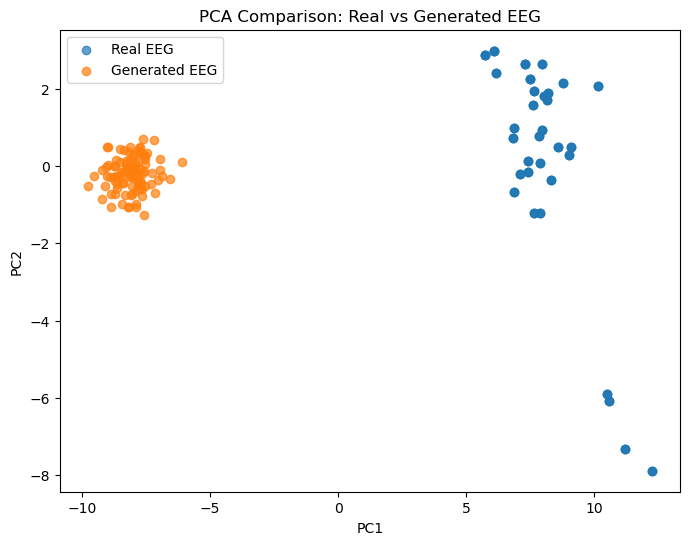

In [152]:
import matplotlib.pyplot as plt

# =========================
# PCA 결과 분리
# =========================

real_pca = pca_result[:len(real_features)]

gen_pca = pca_result[len(real_features):]

# =========================
# Scatter Plot
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    real_pca[:,0],
    real_pca[:,1],
    alpha=0.7,
    label="Real EEG"
)

plt.scatter(
    gen_pca[:,0],
    gen_pca[:,1],
    alpha=0.7,
    label="Generated EEG"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Comparison: Real vs Generated EEG")

plt.legend()

plt.show()